# Bandas espectrais não-visíveis melhoram a classificação de uso do solo?
## Um estudo com EuroSAT (Sentinel-2) e CNNs

---

### Objetivo
Avaliar **quantitativamente** se bandas espectrais além do visível — infravermelho próximo (NIR), red-edge e SWIR — melhoram a classificação de uso/cobertura do solo.

### Dataset e problema
O dataset escolhido é o **EuroSAT all-bands**, com imagens Sentinel-2 de 64×64 pixels, 13 bandas espectrais e 10 classes de uso/cobertura do solo. O problema é de **classificação multiclasse**: dada uma cena de satélite, prever a classe correta (Forest, Residential, River, SeaLake etc.).

### Hipótese
> Bandas não-visíveis melhoram a classificação em relação a apenas RGB, especialmente para vegetação e água.

### Metodologia
Treinamos **a mesma CNN** três vezes, mudando apenas os canais de entrada:

| Modelo | Bandas | Canais |
|--------|--------|--------|
| **A — RGB** | B4, B3, B2 | 3 |
| **B — RGB + NIR** | B4, B3, B2, B8 | 4 |
| **C — Multi-espectral** | todas | 13 |

Mesma seed, mesmo split (70/15/15), mesma normalização, mesmos callbacks. A única variável é o conjunto de bandas → comparação justa.

> Este notebook não retreina os modelos para caber no tempo de apresentação. Ele carrega os resultados gerados pelos notebooks `03`–`05`, mostra o código de consolidação e interpreta as métricas finais.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.metrics import classification_report, precision_score, recall_score

from src import config, evaluation
from src import visualization as viz

MODELS = {
    'A — RGB': 'model_a_rgb',
    'B — RGB+NIR': 'model_b_rgb_nir',
    'C — Multi-espectral': 'model_c_multispectral',
}

metrics = {label: evaluation.load_metrics(config.METRICS_DIR / f'{name}.json') for label, name in MODELS.items()}
histories = {label: json.loads((config.HISTORIES_DIR / f'{name}.json').read_text()) for label, name in MODELS.items()}
print('Resultados carregados:', list(metrics))

Resultados carregados: ['A — RGB', 'B — RGB+NIR', 'C — Multi-espectral']


## 1. Dataset e pré-processamento

O EuroSAT all-bands já fornece cenas Sentinel-2 recortadas em **64×64 pixels**, então não foi necessário redimensionar as imagens. O pré-processamento do projeto foi:

- split determinístico em treino/validação/teste (**70/15/15**);
- seleção de canais conforme o experimento A, B ou C;
- normalização **z-score por banda**, calculada apenas no treino e reaproveitada em validação/teste;
- data augmentation apenas no treino, com flips horizontal/vertical e rotações de 90°.

Essas escolhas evitam vazamento de informação do teste e preservam a assinatura espectral das bandas Sentinel-2.

In [2]:
preprocess_summary = pd.DataFrame([
    {'Etapa': 'Dataset', 'Configuração': 'EuroSAT all-bands / Sentinel-2 / 64×64 / 13 bandas / 10 classes'},
    {'Etapa': 'Split', 'Configuração': f'{config.TRAIN_FRAC:.0%} treino, {config.VAL_FRAC:.0%} validação, {config.TEST_FRAC:.0%} teste'},
    {'Etapa': 'Modelo A', 'Configuração': ', '.join(config.BAND_NAMES[i] for i in config.RGB_INDICES)},
    {'Etapa': 'Modelo B', 'Configuração': ', '.join(config.BAND_NAMES[i] for i in config.RGB_NIR_INDICES)},
    {'Etapa': 'Modelo C', 'Configuração': ', '.join(config.BAND_NAMES[i] for i in config.ALL_INDICES)},
    {'Etapa': 'Normalização', 'Configuração': 'z-score por banda calculado somente no treino'},
    {'Etapa': 'Augmentation', 'Configuração': 'RandomFlip horizontal/vertical + rotação aleatória de 0/90/180/270°'},
])
preprocess_summary

,Etapa,Configuração
0,Dataset,EuroSAT all-bands / Sentinel-2 / 64×64 / 13 ba...
1,Split,"70% treino, 15% validação, 15% teste"
2,Modelo A,"B4, B3, B2"
3,Modelo B,"B4, B3, B2, B8"
4,Modelo C,"B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B10, ..."
5,Normalização,z-score por banda calculado somente no treino
6,Augmentation,RandomFlip horizontal/vertical + rotação aleat...


## 2. Arquitetura da CNN e procedimento de treino

A arquitetura é a mesma nos três experimentos; só muda o número de canais de entrada. Cada bloco convolucional usa duas convoluções 3×3 com `padding='same'`, `BatchNormalization` e `ReLU`, seguido de `MaxPooling2D`. No topo, `GlobalAveragePooling2D`, `Dropout(0.3)` e uma `Dense` softmax de 10 classes.

O treino usa Adam, perda `sparse_categorical_crossentropy`, early stopping pelo melhor `val_accuracy`, redução de learning rate em platô e checkpoint do melhor modelo. O limite é de 50 épocas, mas o early stopping pode parar antes.

In [3]:
architecture = pd.DataFrame([
    {'Bloco': 'Entrada', 'Camadas': '64×64×C, com C = 3, 4 ou 13'},
    {'Bloco': 'Conv 1', 'Camadas': '2× Conv2D(32, 3×3) + BatchNorm + ReLU + MaxPool2D'},
    {'Bloco': 'Conv 2', 'Camadas': '2× Conv2D(64, 3×3) + BatchNorm + ReLU + MaxPool2D'},
    {'Bloco': 'Conv 3', 'Camadas': '2× Conv2D(128, 3×3) + BatchNorm + ReLU + MaxPool2D'},
    {'Bloco': 'Cabeça', 'Camadas': 'GlobalAveragePooling2D + Dropout(0.3) + Dense(10, softmax)'},
])

training_setup = pd.DataFrame([
    {'Item': 'Batch size', 'Valor': config.BATCH_SIZE},
    {'Item': 'Épocas máximas', 'Valor': config.EPOCHS},
    {'Item': 'Otimizador', 'Valor': f'Adam, learning rate={config.LEARNING_RATE:g}'},
    {'Item': 'Loss', 'Valor': 'sparse_categorical_crossentropy'},
    {'Item': 'Métrica de treino', 'Valor': 'accuracy'},
    {'Item': 'Callbacks', 'Valor': 'ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard'},
    {'Item': 'Parâmetros', 'Valor': 'A: 289.642 | B: 289.930 | C: 292.522'},
])

display(architecture)
display(training_setup)

,Bloco,Camadas
0,Entrada,"64×64×C, com C = 3, 4 ou 13"
1,Conv 1,"2× Conv2D(32, 3×3) + BatchNorm + ReLU + MaxPool2D"
2,Conv 2,"2× Conv2D(64, 3×3) + BatchNorm + ReLU + MaxPool2D"
3,Conv 3,"2× Conv2D(128, 3×3) + BatchNorm + ReLU + MaxPo..."
4,Cabeça,GlobalAveragePooling2D + Dropout(0.3) + Dense(...


,Item,Valor
0,Batch size,64
1,Épocas máximas,50
2,Otimizador,"Adam, learning rate=0.001"
3,Loss,sparse_categorical_crossentropy
4,Métrica de treino,accuracy
5,Callbacks,"ModelCheckpoint, EarlyStopping, ReduceLROnPlat..."
6,Parâmetros,A: 289.642 | B: 289.930 | C: 292.522


## 3. Tabela comparativa

In [4]:
table = viz.build_comparison_table(metrics)
table

,Modelo,Acurácia,F1 macro,Tempo treino (s),Parâmetros
0,A — RGB,0.9820,0.9813,246.6,289642
1,B — RGB+NIR,0.9805,0.9795,223.6,289930
2,C — Multi-espectral,0.9862,0.9852,1076.7,292522


## 4. Precisão, recall e F1-score

Além da acurácia, usamos métricas macro para evitar que uma classe esconda o desempenho de outra. Também exibimos precisão, recall e F1 por classe para o melhor modelo, como complemento à matriz de confusão.

In [5]:
quality_rows = []
for label, m in metrics.items():
    y_true = np.asarray(m['y_true'])
    y_pred = np.asarray(m['y_pred'])
    quality_rows.append({
        'Modelo': label,
        'Acurácia': m['accuracy'],
        'Precisão macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 macro': m['f1_macro'],
    })

quality_table = pd.DataFrame(quality_rows).round(4)
quality_table

,Modelo,Acurácia,Precisão macro,Recall macro,F1 macro
0,A — RGB,0.9820,0.9811,0.9816,0.9813
1,B — RGB+NIR,0.9805,0.9792,0.9799,0.9795
2,C — Multi-espectral,0.9862,0.9853,0.9852,0.9852


In [6]:
best_label = max(metrics, key=lambda label: metrics[label]['f1_macro'])
best_metrics = metrics[best_label]
report = classification_report(
    best_metrics['y_true'],
    best_metrics['y_pred'],
    labels=range(len(config.CLASS_NAMES)),
    target_names=config.CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

per_class_quality = (
    pd.DataFrame(report)
    .T.loc[config.CLASS_NAMES, ['precision', 'recall', 'f1-score', 'support']]
    .rename(columns={'precision': 'Precisão', 'recall': 'Recall', 'f1-score': 'F1-score', 'support': 'Suporte'})
    .round(4)
)
print(f'Melhor modelo por F1 macro: {best_label}')
per_class_quality

Melhor modelo por F1 macro: C — Multi-espectral


,Precisão,Recall,F1-score,Suporte
AnnualCrop,0.9789,0.9766,0.9777,427.0
Forest,0.9935,0.9978,0.9956,458.0
HerbaceousVegetation,0.9774,0.9774,0.9774,442.0
Highway,0.9796,0.9821,0.9809,392.0
Industrial,0.9900,0.9900,0.9900,402.0
Pasture,0.9721,0.9654,0.9688,289.0
PermanentCrop,0.9777,0.9804,0.9790,357.0
Residential,1.0000,0.9978,0.9989,452.0
River,0.9862,0.9862,0.9862,362.0
SeaLake,0.9979,0.9979,0.9979,469.0


## 5. Curvas de validação lado a lado

Quão rápido e quão alto cada modelo converge.

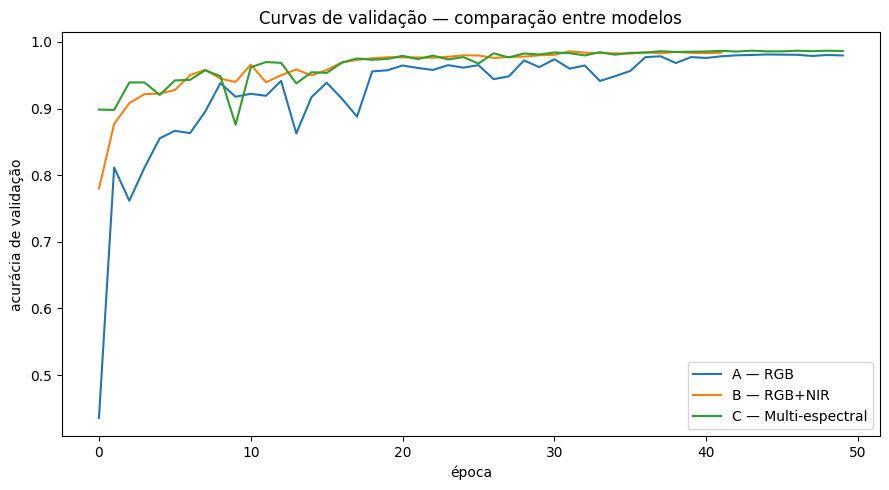

In [7]:
viz.plot_curves_side_by_side(histories, save_path=config.FIGURES_DIR / 'comparison_curves.png')
plt.show()

## 6. Acurácia no teste — comparação direta

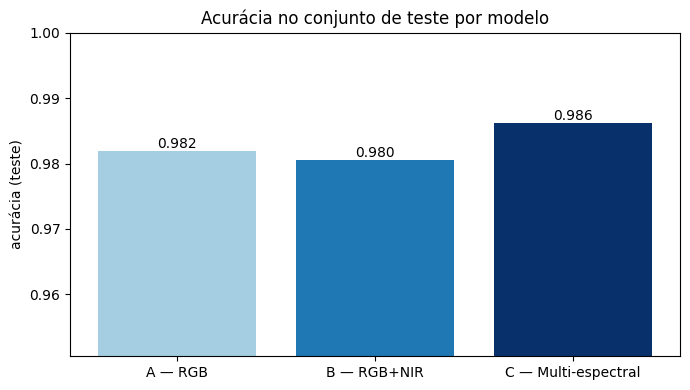

In [8]:
accs = [metrics[k]['accuracy'] for k in MODELS]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(list(MODELS), accs, color=['#a6cee3', '#1f78b4', '#08306b'])
ax.set_ylabel('acurácia (teste)'); ax.set_ylim(min(accs) - 0.03, 1.0)
ax.set_title('Acurácia no conjunto de teste por modelo')
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, a, f'{a:.3f}', ha='center', va='bottom')
plt.tight_layout(); fig.savefig(config.FIGURES_DIR / 'comparison_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Matrizes de confusão lado a lado

Normalizadas por linha (mostram a taxa de acerto/erro por classe real).

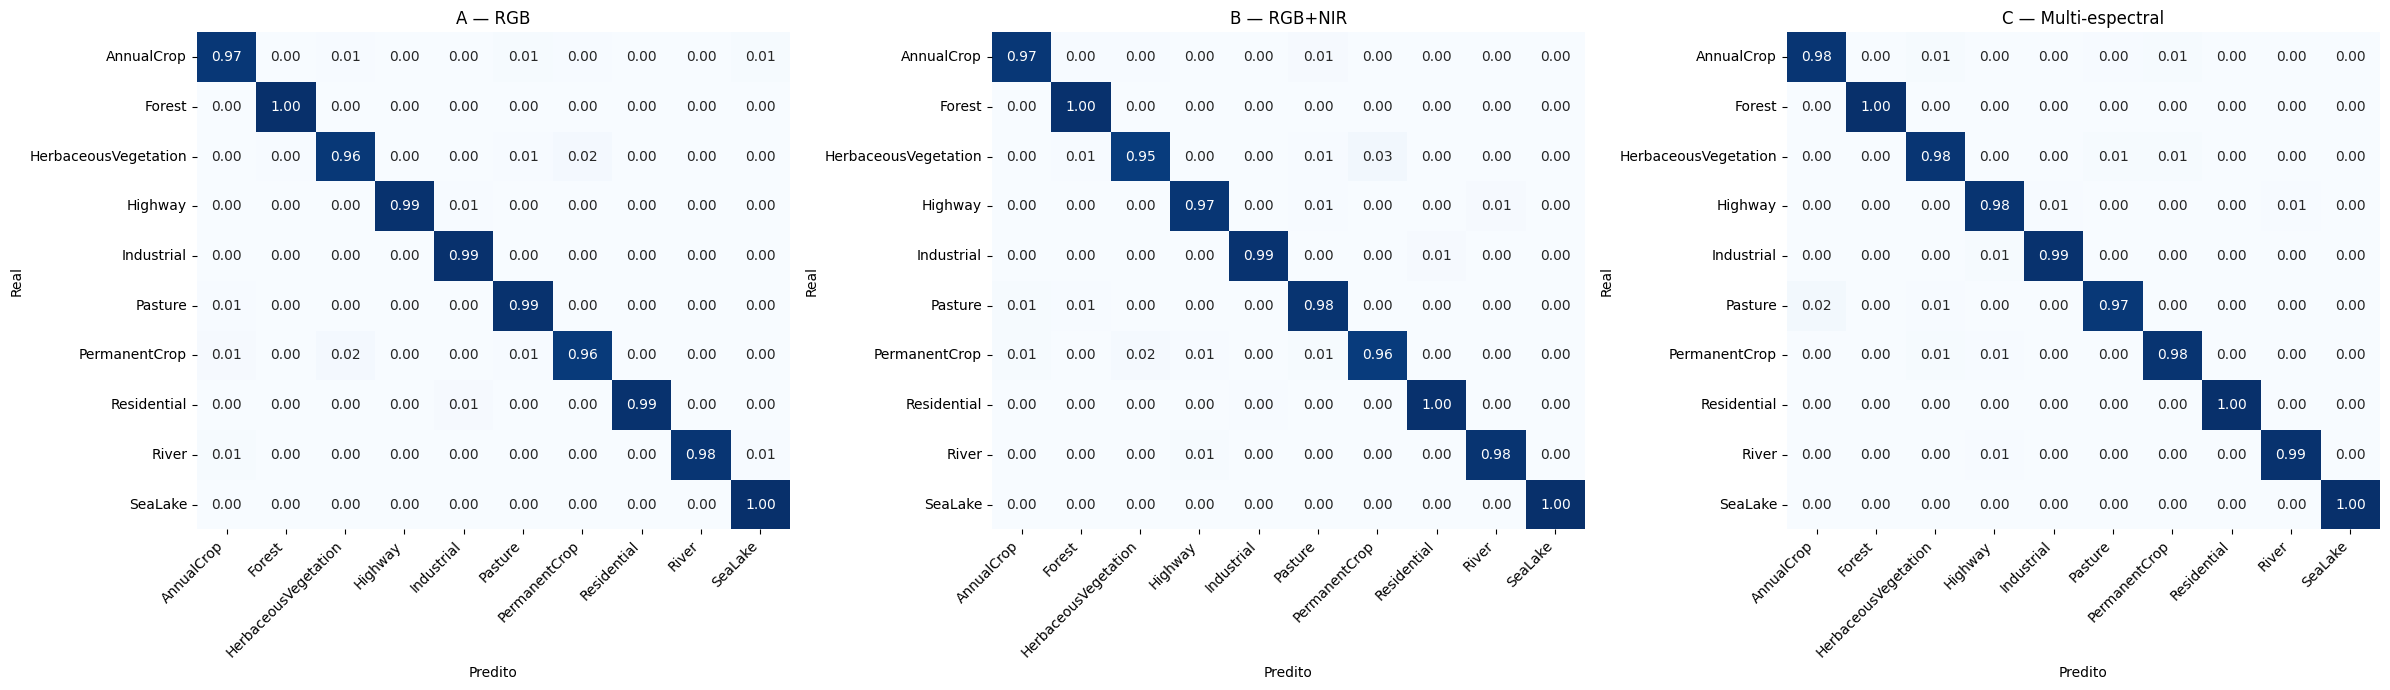

In [9]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, (label, m) in zip(axes, metrics.items()):
    cm, _ = evaluation.compute_confusion_matrix(m['y_true'], m['y_pred'])
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues', cbar=False,
                xticklabels=config.CLASS_NAMES, yticklabels=config.CLASS_NAMES, ax=ax)
    ax.set_title(label); ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(); fig.savefig(config.FIGURES_DIR / 'comparison_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. F1 por classe — quem se beneficia das bandas extras?

Esperamos ganho maior em vegetação (NIR) e água/sombra (SWIR).

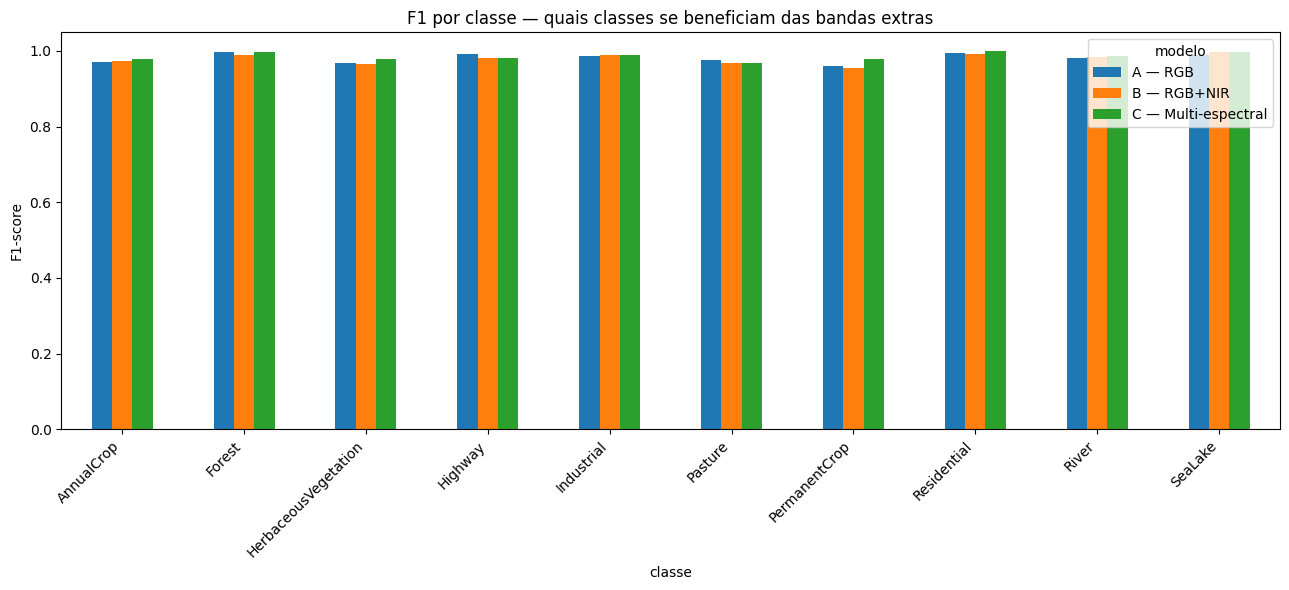

,A (RGB),C (13 bandas),Ganho (C - A)
PermanentCrop,0.960674,0.979021,0.0183
HerbaceousVegetation,0.968182,0.977376,0.0092
SeaLake,0.989429,0.997868,0.0084
AnnualCrop,0.971765,0.977726,0.0060
River,0.980556,0.986188,0.0056
Residential,0.993318,0.998893,0.0056
Industrial,0.985185,0.990050,0.0049
Forest,0.995633,0.995643,0.0000
Pasture,0.976109,0.968750,-0.0074
Highway,0.992327,0.980892,-0.0114


In [10]:
viz.plot_per_class_comparison(metrics, save_path=config.FIGURES_DIR / 'comparison_per_class.png')
plt.show()

# Ganho de F1 por classe: Modelo C menos Modelo A.
delta = pd.DataFrame({
    'A (RGB)': metrics['A — RGB']['f1_per_class'],
    'C (13 bandas)': metrics['C — Multi-espectral']['f1_per_class'],
})
delta['Ganho (C - A)'] = (delta['C (13 bandas)'] - delta['A (RGB)']).round(4)
delta.sort_values('Ganho (C - A)', ascending=False)

## 9. Por que o NIR ajuda — análise via NDVI

O NDVI = (B8 − B4) / (B8 + B4) usa uma banda não-visível (B8) para separar vegetação de construção. A figura abaixo foi gerada previamente a partir de amostras do EuroSAT e fica salva em `results/figures/ndvi_analysis.png`, evitando download do dataset durante a apresentação.

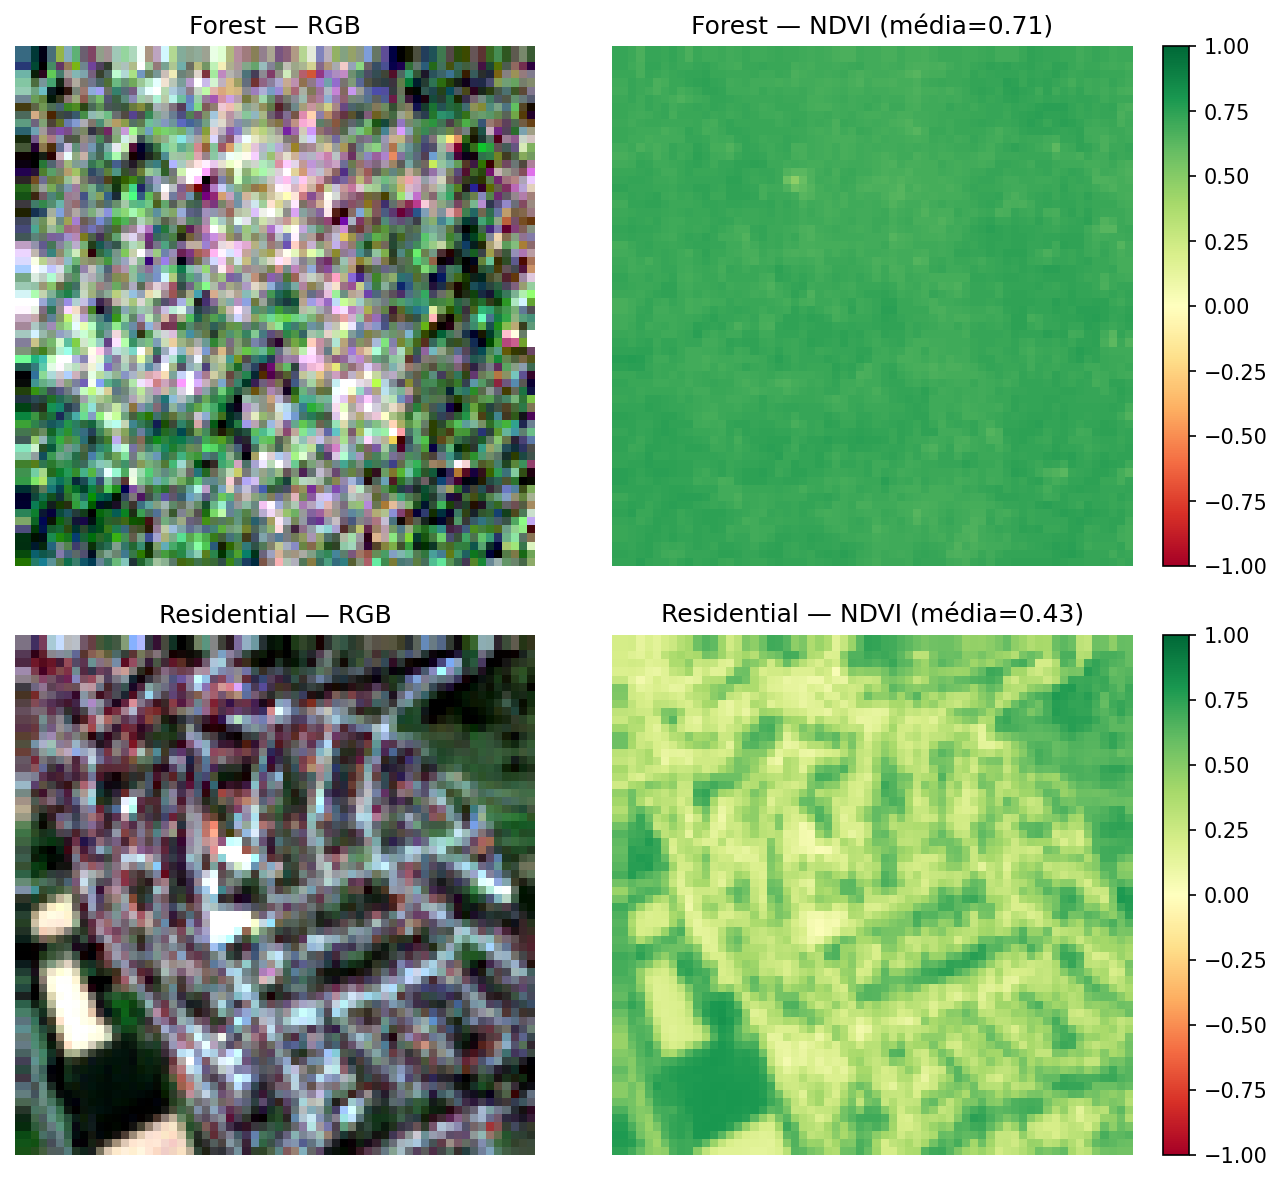

In [11]:
ndvi_path = config.FIGURES_DIR / 'ndvi_analysis.png'
if not ndvi_path.exists():
    raise FileNotFoundError(f'Figura esperada não encontrada: {ndvi_path}')

display(Image(filename=str(ndvi_path)))

## 10. Conclusão

**Resultado principal.** Os três modelos superaram com folga a meta de 85%, atingindo no conjunto de teste:

| Modelo | Acurácia | F1 macro |
|--------|----------|----------|
| A — RGB | 98,20% | 0,9813 |
| B — RGB+NIR | 98,05% | 0,9795 |
| C — Multi-espectral | **98,62%** | **0,9852** |

A ordem observada foi **C > A > B**. O modelo com **todas as 13 bandas foi o melhor**, confirmando a hipótese de que bandas não-visíveis agregam informação útil — porém o ganho sobre o RGB puro foi **pequeno: +0,42 ponto percentual de acurácia** (+0,39 em F1 macro).

**Um achado honesto:** adicionar **apenas o NIR** (modelo B) **não ajudou** — ficou inclusive levemente abaixo do RGB (98,05% vs 98,20%), dentro da margem de ruído de uma única seed. Ou seja, não houve o ganho monotônico A < B < C que se poderia esperar; o benefício só apareceu de forma consistente ao usar o **conjunto completo** de bandas (incluindo red-edge B5–B7 e SWIR B11–B12), não o NIR isolado.

**Onde as bandas extras ajudaram** (ganho de F1 por classe, C − A):
- **PermanentCrop +0,018** — culturas permanentes (pomares/vinhedos), difíceis de separar só no visível, têm assinatura espectral distinta.
- **HerbaceousVegetation +0,009** e **AnnualCrop +0,006** — tipos de vegetação.
- **SeaLake +0,008** — água, onde o SWIR dá bom contraste.

São justamente classes de **vegetação e água** — coerente com a hipótese e com a física do NDVI. Em contrapartida, **Highway (−0,011)** e **Pasture (−0,007)** pioraram um pouco, e **Forest** já estava saturada (F1 ≈ 0,996 nos dois modelos), sem espaço para melhora.

**Custo.** O nº de parâmetros quase não muda (290k → 293k; só a 1ª camada cresce). Já o **tempo de treino foi ~4× maior** no modelo C (≈18 min vs ≈4 min), pelo volume de dados (13 bandas) lido a cada época.

**Interpretação geral.** No EuroSAT, o **RGB sozinho já resolve ~98%** do problema — esse teto alto deixa pouca margem para as bandas extras brilharem. Elas trazem ganho real, mas modesto, concentrado em classes de vegetação/água. Num problema mais difícil (mais classes, mais confusão espectral), é razoável esperar uma vantagem maior do multi-espectral.

### Limitações
- Resultados de **uma única seed** — as diferenças de ~0,4 pp estão na ordem do ruído de treino; o ideal é repetir com várias seeds.
- EuroSAT é relativamente "fácil" e bem balanceado; o teto de acurácia alto **mascara** diferenças entre os modelos.
- Imagens 64×64 já pré-recortadas por classe — não reflete um cenário de segmentação real.

### Trabalhos futuros
- Rodar com **3+ seeds** e reportar média ± desvio (com teste estatístico) para confirmar se C > A é significativo.
- Adicionar **índices derivados** (NDVI, NDWI, NDBI) como canais extras de entrada.
- Testar **arquiteturas maiores** ou transfer learning, e datasets mais desafiadores.